![](https://indico.desy.de/event/50246/attachments/99407/137562/Banner%20DLS%20Advanced%202026.jpg)

# Normalizing Flows

Lecturer: José Ignacio Robledo

In this hands-on tutorial, we will learn a non-Gaussian 2D density, inspect the change-of-variables computation, compare coupling and autoregressive/spline architectures, train a continuous normalizing flow, and finish with a conditional flow. 

Throughout this tutorial, we will be using [`Zuko`](https://zuko.readthedocs.io/stable/index.html), a Python Package that implements normalizing flows in `PyTorch`.  By the end of this tutorial, it is intended that you learn how to:

1. use `log_prob` and `sample` through Zuko's distribution interface;
2. train a Normalizing Flow by maximum likelihood estimation (MLE);
3. explore you Normalizing Flow model in data space and latent space;
4. choose between different transformations: coupling, autoregressive, spline, and continuous flows;
5. condition a flow on observed information.

You will find cells marked with **Your turn**. These are the core activities. Solutions are found in the solutions notebook, where the whole notebook is runnable end-to-end.

## Setup

If needed, uncomment the installation line. Zuko requires PyTorch and exposes a flow as a `torch.nn.Module`; calling the module returns a `torch.distributions.Distribution`-like object.

We will first set a random seed for reproducibility, and then detect the device to run on. Feel free to choose the device of your convenience. 

In [4]:
# %pip install -q zuko matplotlib

import math
import time
import numpy as np
import matplotlib.pyplot as plt
import torch
import zuko

SEED = 7
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(f"device={DEVICE} | torch={torch.__version__} | zuko={zuko.__version__}")

plt.style.use("ggplot")

device=mps | torch=2.5.1 | zuko=1.4.1


## From a simple density to a complex one

A flow learns an invertible transformation between data $x$ and a simple latent variable $z$:

$$z=f_\theta(x), \qquad z\sim p_Z(z).$$

In the lecture, we saw that the density is exact because

$$\log p_X(x)=\log p_Z(f_\theta(x))+\log\left|\det\frac{\partial f_\theta(x)}{\partial x}\right|.$$

The base density rewards mapping observations to plausible latent points; the log-Jacobian corrects for local volume expansion or contraction.

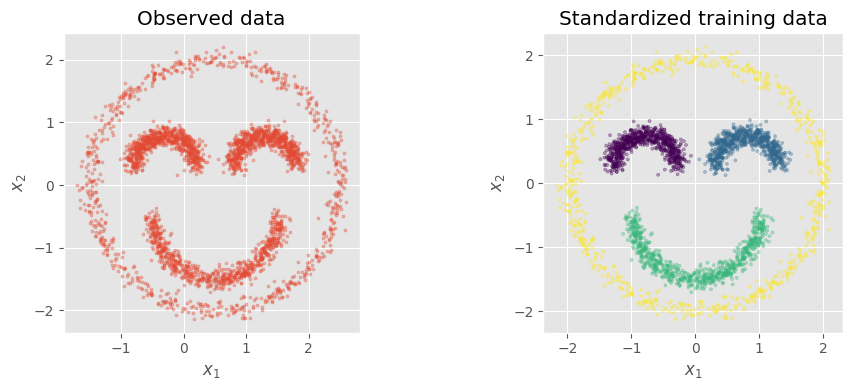

In [80]:
def sample_moons(n=3000, noise=0.08, shift=0.0, device=DEVICE):
    n1 = n // 4
    t1 = torch.rand(n1, device=device) * math.pi
    t2 = torch.rand(n1, device=device) * math.pi
    t3 = torch.rand(n1, device=device) * 2* math.pi
    eye1 = torch.stack((-0.3+0.5*torch.cos(t1), 0.3 + 0.5*torch.sin(t1)), dim=-1)
    eye2 = torch.stack((1.3+0.5*torch.cos(t1), 0.3 + 0.5*torch.sin(t1)), dim=-1)
    mouth = torch.stack((0.5 - torch.cos(t2), -torch.sin(t2) - 0.5), dim=-1)
    head = torch.stack((0.5 - 2*torch.cos(t3), 2*torch.sin(t3)), dim=-1)
    x = torch.cat((eye1, eye2, mouth, head)) + noise * torch.randn(n, 2, device=device)
    x[:, 0] += shift
    
    labels = torch.cat((
        torch.zeros(n1, 1, device=device),
        torch.ones(n1, 1, device=device),
        2*torch.ones(n1, 1, device=device),
        3*torch.ones(n1, 1, device=device),
    ))
     
    permutation = torch.randperm(n, device=device)
    return x[permutation], labels[permutation]

n=3000
raw, labels = sample_moons()
mean, std = raw.mean(0), raw.std(0).clamp_min(1e-5)
x_train = (raw - mean) / std

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(*raw.cpu().T, s=5, alpha=.35)
ax[0].set(title="Observed data", xlabel="$x_1$", ylabel="$x_2$", aspect="equal")
ax[1].scatter(*x_train.cpu().T, s=5, alpha=.35, c=labels.cpu())
ax[1].set(title="Standardized training data", xlabel="$x_1$", ylabel="$x_2$", aspect="equal")
plt.tight_layout()

### 1.) Your turn: establish a baseline

Before using a flow, fit (simplest: search by hand a good candidate; more complex: use an optimization algorithm of your choice) an isotropic standard Normal using `torch.distributions.Normal`. What qualitative feature of the database can it capture? Compute its mean negative log-likelihood (NLL); lower is better.

Standard Normal NLL: 1.481


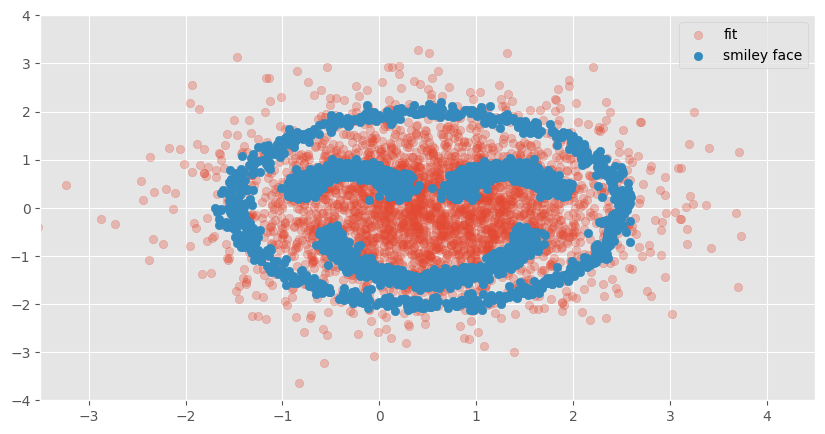

In [137]:
# Solution

base = torch.distributions.Normal(torch.tensor([0.5, 0.0], device=DEVICE), torch.ones(2, device=DEVICE))

baseline_nll = -base.log_prob(x_train).mean()
print(f"Standard Normal NLL: {baseline_nll:.3f}")

plt.figure(figsize=(10,5))
plt.scatter(*base.sample((n,)).cpu().T, alpha=0.3, label='fit')
plt.xlim(-3.5,4.5)
plt.ylim(-4,4)
plt.scatter(*raw.cpu().T, label='smiley face')
plt.legend();

## Coupling flows: train a flexible exact density

An affine coupling layer splits the input features in two subsets $x=(x_A,x_B)$, leaves one subset unchanged and transforms the other in the following way:

$$y_A=x_A,\qquad y_B=x_B\odot\exp s_\theta(x_A)+t_\theta(x_A).$$

We saw in the lectures that this makes inversion cheap and the Jacobian triangular. Alternating masks across layers lets every dimension change. In Zuko, `NICE` implements a stack of coupling transformations (despite the historical name, Zuko's default transformer is affine).

In [116]:
flow = zuko.flows.NICE(
    features=2,
    transforms=6,
    hidden_features=(64, 64),
).to(DEVICE)

dist = flow()  # unconditional distribution since no context has been provided
print(dist)
print("log_prob shape for the 10 first training samples:", dist.log_prob(x_train[:10]).shape)
print("sample shape when sampling 10 new datapoints:  ", dist.sample((10,)).shape)
print("trainable parameters:", sum(p.numel() for p in flow.parameters()))

NormalizingFlow(
  (transform): ComposedTransform(
    (0): CouplingTransform()
    (1): CouplingTransform()
    (2): CouplingTransform()
    (3): CouplingTransform()
    (4): CouplingTransform()
    (5): CouplingTransform()
  )
  (base): DiagNormal(loc: torch.Size([2]), scale: torch.Size([2]))
)
log_prob shape for the 10 first training samples: torch.Size([10])
sample shape when sampling 10 new datapoints:   torch.Size([10, 2])
trainable parameters: 26508


We can verify that without training, we are just in a random normal distribution

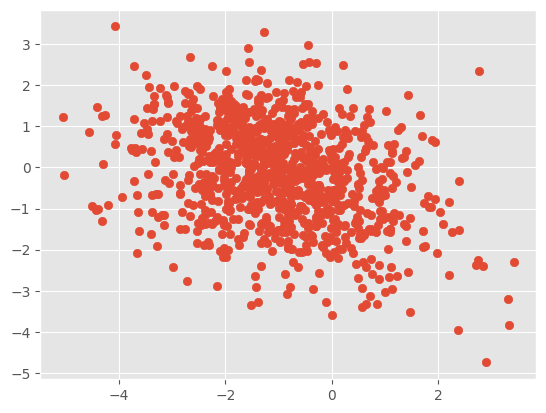

In [117]:
plt.scatter(*dist.sample((1000,)).T.cpu());

### 2.) Your turn: write the learning objective

Fill in the missing expression conceptually before revealing the solution:

```python
loss = ???
```

We observe samples from the data distribution and maximize their likelihood under the model. Write down the loss in the training loop

step    1 | NLL 1.916
step  100 | NLL 1.713
step  200 | NLL 1.727
step  300 | NLL 1.950
step  400 | NLL 1.788
step  500 | NLL 1.668


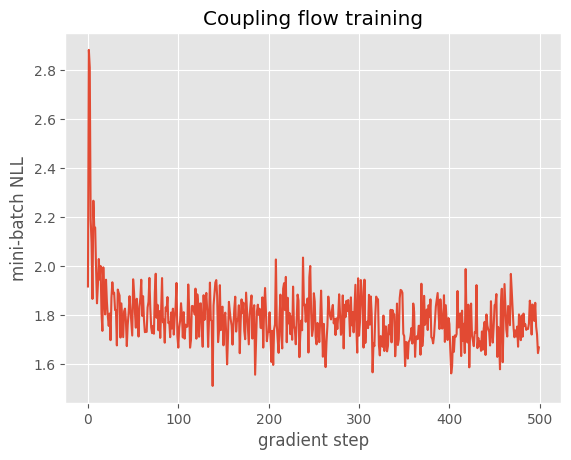

In [131]:
def train_flow(flow, data, steps=500, batch_size=256, lr=2e-3, report_every=100):
    optimizer = torch.optim.Adam(flow.parameters(), lr=lr)
    losses = []
    flow.train()

    for step in range(1, steps + 1):
        idx = torch.randint(len(data), (batch_size,), device=data.device)
        batch = data[idx]

        # Solution: maximum likelihood = minimize the negative log-likelihood.
        loss = -flow().log_prob(batch).mean()

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(flow.parameters(), 5.0)
        optimizer.step()
        losses.append(loss.item())

        if step == 1 or step % report_every == 0:
            print(f"step {step:4d} | NLL {loss.item():.3f}")

    return losses

start = time.perf_counter()
losses = train_flow(flow, x_train, steps=500)
end = start = time.perf_counter()
time_nice = end - start
plt.plot(losses)
plt.xlabel("gradient step"); plt.ylabel("mini-batch NLL"); plt.title("Coupling flow training")
plt.show()

### 3.) Your turn: sample and evaluate

Generate 4000 samples and compare them to the observations. Then compare the final full-data NLL with the Gaussian baseline. A good likelihood does not guarantee visually perfect samples, so inspect both.

baseline NLL=1.481 | flow NLL=1.740


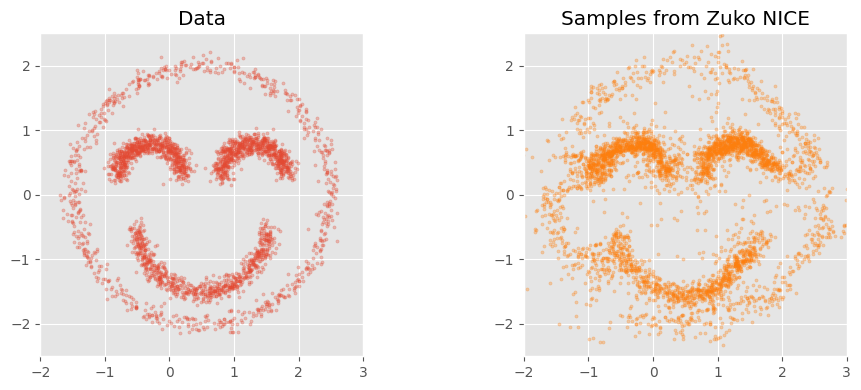

baseline NLL=1.481 | flow NLL=1.740


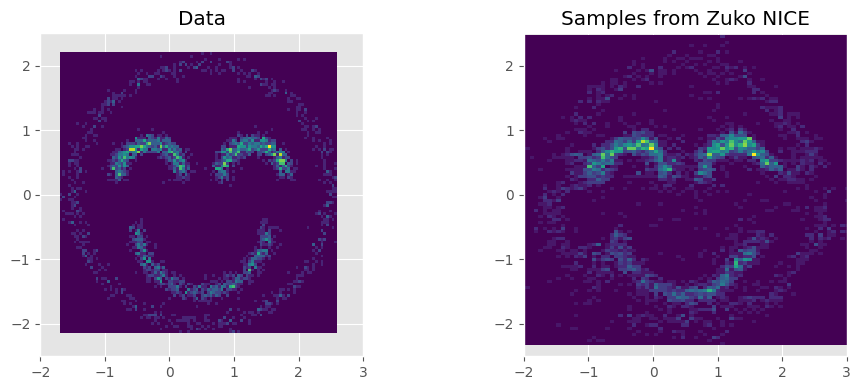

In [133]:
flow.eval()
with torch.no_grad():
    # Solution
    learned = flow()
    samples_std = learned.sample((4000,))
    samples = samples_std * std + mean
    trained_nll = -learned.log_prob(x_train).mean()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(*raw.cpu().T, s=5, alpha=.3)
ax[0].set(title="Data", aspect="equal")
ax[0].set_xlim(-2, 3)
ax[0].set_ylim(-2.5, 2.5)

ax[1].scatter(*samples.cpu().T, s=5, alpha=.3, color="tab:orange")
ax[1].set(title="Samples from Zuko NICE", aspect="equal")
ax[1].set_xlim(-2, 3)
ax[1].set_ylim(-2.5, 2.5)

plt.tight_layout()
print(f"baseline NLL={baseline_nll:.3f} | flow NLL={trained_nll:.3f}")
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist2d(*raw.cpu().T, bins=100)
ax[0].set(title="Data", aspect="equal")
ax[0].set_xlim(-2, 3)
ax[0].set_ylim(-2.5, 2.5)

ax[1].hist2d(*samples.cpu().T, bins=100)
ax[1].set(title="Samples from Zuko NICE", aspect="equal")
ax[1].set_xlim(-2, 3)
ax[1].set_ylim(-2.5, 2.5)
plt.tight_layout()
print(f"baseline NLL={baseline_nll:.3f} | flow NLL={trained_nll:.3f}")
plt.show()


## Look inside the learned change of variables

For density evaluation, Zuko transforms $x\to z$. For sampling, it draws $z\sim\mathcal N(0,I)$ and applies the inverse transformation. We can access that transform through the returned distribution.

maximum round-trip error: 1.7881393432617188e-06


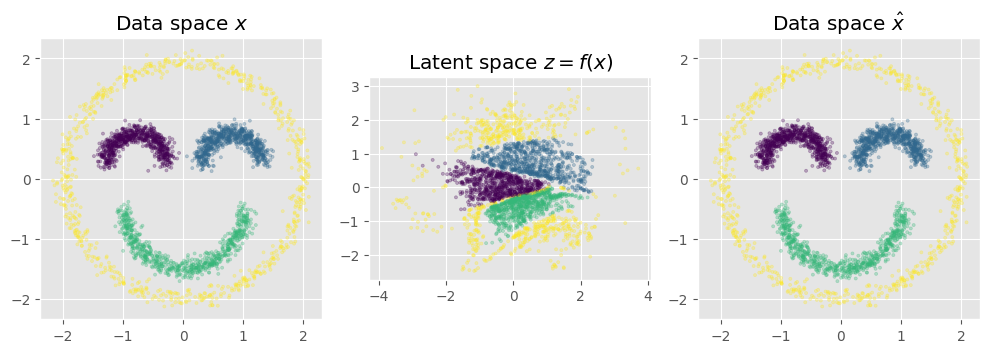

In [134]:
with torch.no_grad():
    z = learned.transform(x_train)
    x_roundtrip = learned.transform.inv(z)

print("maximum round-trip error:", (x_train - x_roundtrip).abs().max().item())

fig, ax = plt.subplots(1, 3, figsize=(10, 4))
ax[0].scatter(*x_train.cpu().T, s=5, alpha=.3, c=labels.cpu())
ax[0].set(title="Data space $x$", aspect="equal")
ax[1].scatter(*z.cpu().T, s=5, alpha=.3, c=labels.cpu())
ax[1].set(title="Latent space $z=f(x)$", aspect="equal")
ax[2].scatter(*x_roundtrip.cpu().T, s=5, alpha=.3, c=labels.cpu())
ax[2].set(title=r"Data space $\hat x$", aspect="equal")
plt.tight_layout();

### 4.) Your turn: check the change-of-variables identity

For a small batch, verify numerically that `dist.log_prob(x)` equals the base log-density plus the transform's log absolute determinant. The sign/direction is a common source of mistakes.

In [135]:
xb = x_train[:16]
zb = learned.transform(xb)
log_det = learned.transform.log_abs_det_jacobian(xb, zb)

lhs = learned.log_prob(xb)
rhs = learned.base.log_prob(zb) + log_det
print("largest identity error:", (lhs - rhs).abs().max().item())
assert torch.allclose(lhs, rhs, atol=1e-5)

largest identity error: 0.0


## Testing different architectures!

- **Affine coupling:** similar cost in both directions; several layers are needed.
- **MAF:** fast parallel density evaluation, sequential sampling; well suited to density estimation.
- **NSF:** uses monotonic rational-quadratic splines for more expressive one-dimensional transforms.
- **CNF:** learns an ODE; flexible, but numerical integration is usually more expensive.

We will compare the first three under a small, equal-step training budget. This is an experiment, not a definitive benchmark.

In [138]:
def fit_and_score(name, model, steps=500):
    start = time.perf_counter()
    history = train_flow(model, x_train, steps=steps, report_every=steps)
    seconds = time.perf_counter() - start
    model.eval()
    with torch.no_grad():
        nll = -model().log_prob(x_train).mean().item()
    return {"name": name, "model": model, "nll": nll, "seconds": seconds, "history": history}

models = [
    ("MAF", zuko.flows.MAF(2, transforms=6, hidden_features=(64, 64)).to(DEVICE)),
    ("NSF", zuko.flows.NSF(2, transforms=6, hidden_features=(64, 64), bins=10).to(DEVICE)),
]
results = [{"name": "NICE", "model": flow, "nll": trained_nll.item(), "seconds": time_nice, "history": losses}]
results += [fit_and_score(name, model) for name, model in models]

print("\nArchitecture comparison")
for r in results:
    print(f"{r['name']:>4s} | NLL={r['nll']:.3f} | fit time={r['seconds']:.1f}s")

step    1 | NLL 2.926
step  500 | NLL 1.986
step    1 | NLL 3.220
step  500 | NLL 1.648

Architecture comparison
NICE | NLL=1.740 | fit time=0.0s
 MAF | NLL=1.915 | fit time=13.8s
 NSF | NLL=1.624 | fit time=43.8s


### 5.) Your turn: Benchmark both directions

Predict which model will be slowest at sampling and which will achieve the best NLL. Then measure. Timings vary by device; focus on the order of magnitude and the architectural reason. Finally plot samples from each model

NICE | NLL: 1988537984.0 (   7.22 ms) | sample    3.45 ms
 MAF | NLL: 7691.92041015625 (   4.73 ms) | sample    8.06 ms
 NSF | NLL: 5.182244300842285 (  25.80 ms) | sample   42.33 ms


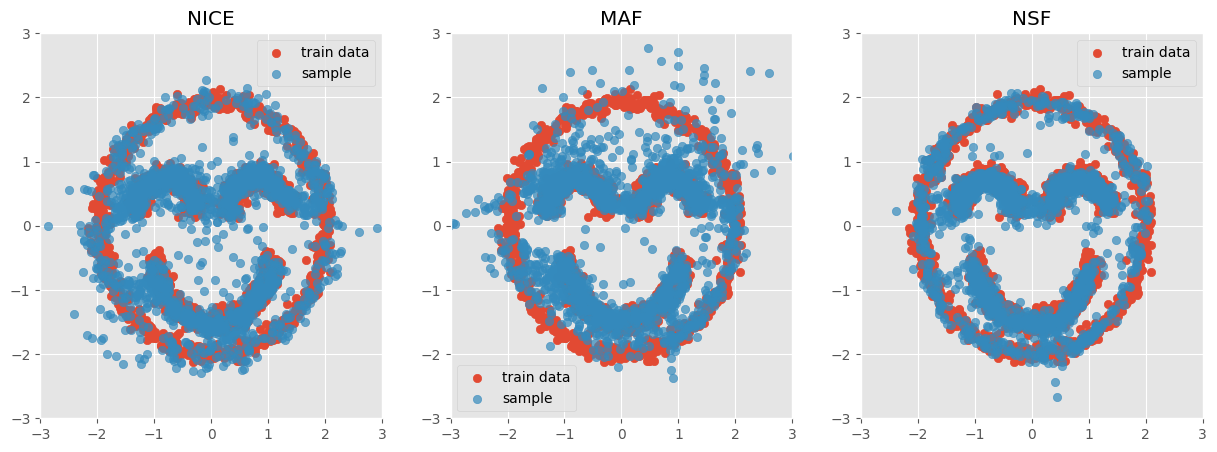

In [149]:
def benchmark(model, n=2048, repeats=20):
    d = model()
    x = torch.randn(n, 2, device=DEVICE)
    with torch.no_grad():
        start = time.perf_counter()
        logprob=0
        for _ in range(repeats): 
            logprob -= d.log_prob(x).mean()
        t_logp = (time.perf_counter() - start) / repeats
        logprob/=repeats
        start = time.perf_counter()
        for _ in range(repeats): 
            samples = d.sample((n,))
        t_sample = (time.perf_counter() - start) / repeats
    return 1000 * t_logp, 1000 * t_sample, logprob, samples

plt.figure(figsize=(15,5))
for i, r in enumerate(results):
    t_logp, t_sample, logprob, samples = benchmark(r["model"])
    print(f"{r['name']:>4s} | NLL: {logprob} ({t_logp:7.2f} ms) | sample {t_sample:7.2f} ms")
    plt.subplot(1,3,i+1)
    plt.scatter(*x_train.T.cpu(), label='train data')
    plt.scatter(*samples.T.cpu(), alpha=0.7, label='sample')
    plt.xlim(-3,3)
    plt.ylim(-3,3)
    plt.legend()
    plt.title(r['name'])
plt.show()
    
# visualize samples from each trained model

## Continuous normalizing flow: learn a smooth transition

A continuous normalizing flow replaces a finite stack of transformations by an ODE:

$$\frac{dx(t)}{dt}=v_\theta(x(t),t), \qquad
\frac{d\log p(x(t))}{dt}=-\operatorname{Tr}\left(\frac{\partial v_\theta}{\partial x}\right).$$

Zuko's `CNF` learns the vector field $v_\theta$. Density evaluation and sampling require numerical integration, so this flexibility has a computational cost.

### 6.) Your turn: train the CNF

1. Instantiate `zuko.flows.CNF` with two features.
2. Train it with the same maximum-likelihood helper function `train_flow` used above.
3. Compare its NLL and wall-clock time with the discrete flows.
4. Predict what happens to runtime if `atol` and `rtol` are made smaller.

step    1 | NLL 2.828
step  200 | NLL 2.397
step  400 | NLL 2.413
CNF | NLL=2.221 | fit time=89.3s


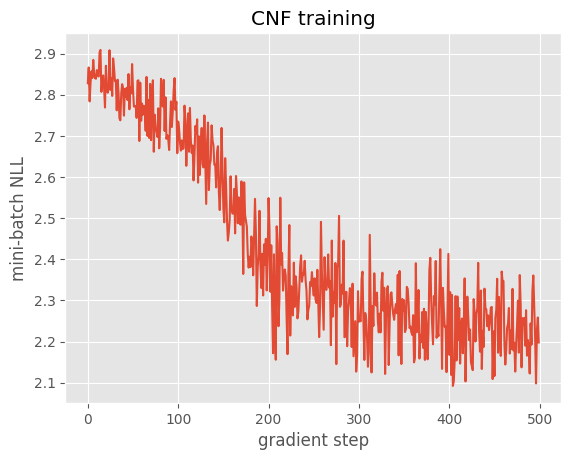

In [153]:
cnf = zuko.flows.CNF(
    features=2,
    hidden_features=(64, 64),
    atol=1e-3,
    rtol=1e-3,
).to(DEVICE)

# CNFs need more optimization than the small discrete-flow comparison above.
start = time.perf_counter()
cnf_losses = train_flow(cnf, x_train, steps=500, batch_size=256, lr=2e-3, report_every=200)
cnf_seconds = time.perf_counter() - start

cnf.eval()
with torch.no_grad():
    cnf_nll = -cnf().log_prob(x_train).mean().item()

print(f"CNF | NLL={cnf_nll:.3f} | fit time={cnf_seconds:.1f}s")
plt.plot(cnf_losses)
plt.xlabel("gradient step"); plt.ylabel("mini-batch NLL"); plt.title("CNF training")
plt.show()

### 7.) Your turn: Create a gid of the continuous transformation

Continue the training for at least 500 steps more, and then visualize in a gif how the gaussian denisty changes towards the smiley face data density

In [ ]:
cnf_losses = train_flow(cnf, x_train, steps=1500, batch_size=256, lr=2e-3, report_every=200)

step    1 | NLL 2.147
step  200 | NLL 2.085
step  400 | NLL 1.973
step  600 | NLL 2.013
step  800 | NLL 1.819
step 1000 | NLL 1.875
step 1200 | NLL 1.635
step 1400 | NLL 1.763


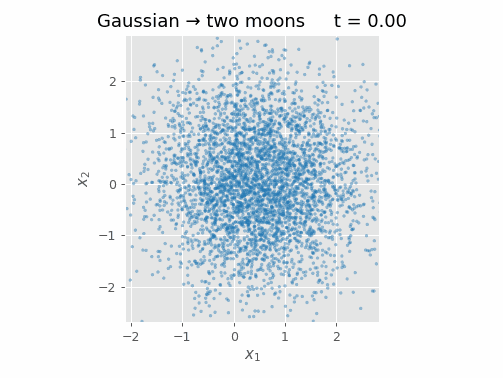

In [ ]:
from pathlib import Path
from IPython.display import Image as DisplayImage, display
from PIL import Image
from zuko.utils import odeint

with torch.no_grad():
    learned_cnf = cnf()
    z0 = learned_cnf.base.sample((4000,))

# Zuko evaluates density from data at ODE time 0 to the Gaussian at time 1.
# Generation follows the learned field in reverse, from time 1 to time 0.
trajectory = []
for alpha in torch.linspace(0, 1, 20):
    with torch.no_grad():
        points = odeint(
            learned_cnf.transform.f,
            z0,
            t0=1.0,
            t1=1.0 - alpha,
            atol=1e-4,
            rtol=1e-4,
        )
        points = points * std + mean
    trajectory.append((float(alpha), points.cpu().numpy()))

all_points = np.concatenate([points for _, points in trajectory])
xlim = np.quantile(all_points[:, 0], [.005, .995]) + [-.15, .15]
ylim = np.quantile(all_points[:, 1], [.005, .995]) + [-.15, .15]

frames = []
for alpha, points in trajectory:
    fig, ax = plt.subplots(figsize=(5.6, 4.2), dpi=90)
    ax.scatter(points[:, 0], points[:, 1], s=7, alpha=.45, color="tab:blue", edgecolors="none")
    ax.set(
        xlim=xlim, ylim=ylim, aspect="equal",
        xlabel="$x_1$", ylabel="$x_2$",
        title=f"Gaussian → two moons     t = {alpha:.2f}",
    )
    fig.tight_layout()
    fig.canvas.draw()
    frame = np.asarray(fig.canvas.buffer_rgba()).copy()
    frames.append(Image.fromarray(frame).convert("P", palette=Image.Palette.ADAPTIVE))
    plt.close(fig)

gif_path = Path("cnf_gaussian_to_smiley_face.gif")
frames[0].save(
    gif_path, save_all=True, append_images=frames[1:],
    duration=130, loop=0, optimize=True,
)
display(DisplayImage(filename=str(gif_path)))

## Conditional normalizing flow challenge

As seen before, we have created thw smiley face fiving labels to each of the modes of the distribution (parts of the face).

- $y=0$: left eye;
- $y=1$: right eye;
- $y=2$: mouth;
- $y=3$: head.

Instead of learning only the mixture $p(x)$, we can also learn $p(x\mid y)$. This gives us control at generation time: one model can sample any part of the face on demand.

### 8.) Your turn 8: learn $p(x \mid y)$

1. Instantiate a conditional NSF with one context feature.
2. Pass the label batch to `conditional(labels)`.
3. Train using the conditional log likelihood $\log p_\theta(x\mid y)$.

In [157]:
conditional = zuko.flows.NSF(
    features=2,
    context=1,
    transforms=6,
    hidden_features=(64, 64),
).to(DEVICE)

optimizer = torch.optim.Adam(conditional.parameters(), lr=2e-3)
cond_losses = []
for step in range(1, 1001):
    idx = torch.randint(len(x_train), (256,), device=DEVICE)
    xb, yb = x_train[idx], labels[idx]

    loss = -conditional(yb).log_prob(xb).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    cond_losses.append(loss.item())

    if step == 1 or step % 100 == 0:
        print(f"step {step:4d} | conditional NLL {loss.item():.3f}")

step    1 | conditional NLL 3.603
step  100 | conditional NLL 0.599
step  200 | conditional NLL 0.275
step  300 | conditional NLL 0.343
step  400 | conditional NLL 0.147
step  500 | conditional NLL 0.233
step  600 | conditional NLL 0.170
step  700 | conditional NLL 0.132
step  800 | conditional NLL 0.140
step  900 | conditional NLL 0.188
step 1000 | conditional NLL 0.086


### 9.) Your Turn: Sample different parts of the face! 

Sample passing the context, with $y=i$, $i=0,...,3$. You can try sampling more of each eye so it has darker eyes :) 

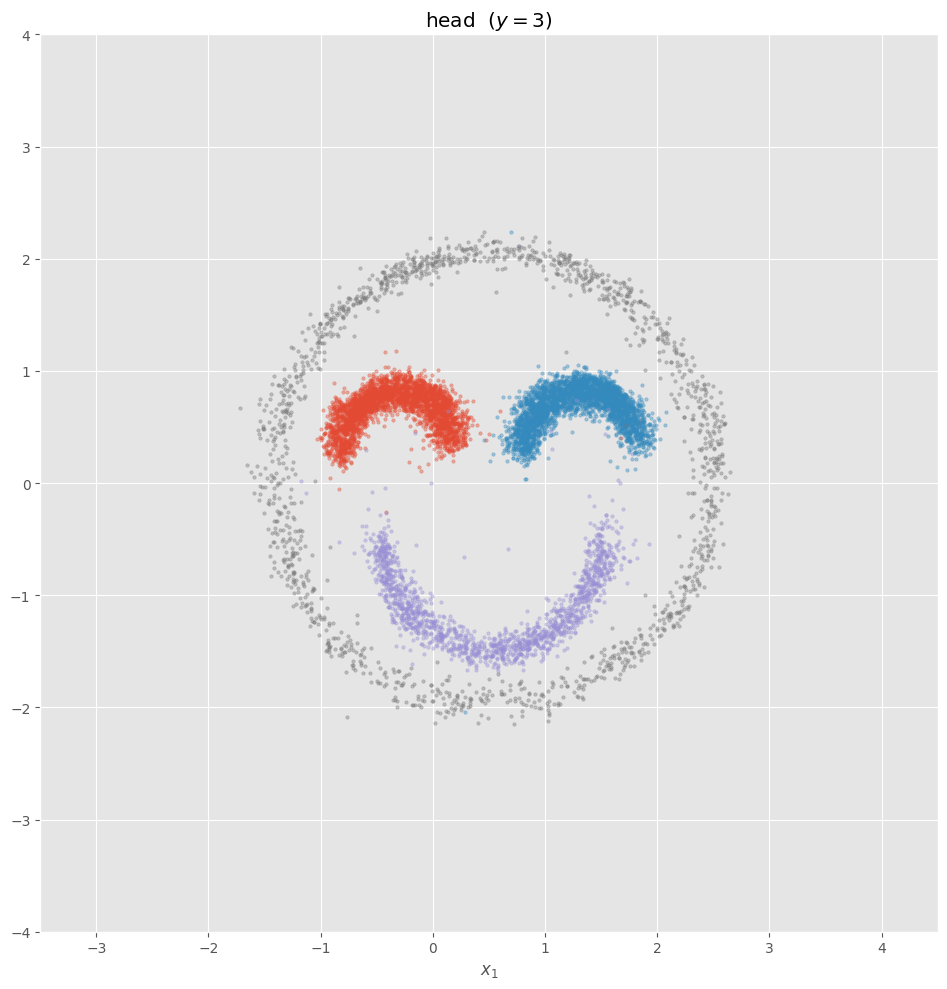

In [159]:
conditional.eval()
moon_names = {0: "left eye", 1: "right eye", 2:"smile", 3:"head"}

fig, ax = plt.subplots(1,1, figsize=(10, 10), sharex=True, sharey=True)
# axes = axes.flatten()
with torch.no_grad():
    # for ax, label in zip(axes, range(0,4)):
    for label in range(0,4):
        context = torch.tensor([[float(label)]], device=DEVICE)
        n_sample = 1500
        if label in [0,1]:
            n_sample = 3000
        samples = conditional(context).sample((n_sample,)).squeeze(1)
        samples = samples * cond_std + cond_mean

        ax.scatter(samples[:, 0].cpu(), samples[:, 1].cpu(), s=6, alpha=.4)
        ax.set(
            title=f"{moon_names[label]}  ($y={label}$)",
            xlabel="$x_1$",
            aspect="equal",
        )
        plt.xlim(-3.5,4.5)
        plt.ylim(-4,4)

axes[0].set_ylabel("$x_2$")
axes[2].set_ylabel("$x_2$")

plt.tight_layout();

## Optional: Try with your data!

It would be great if you have some dataset in your field on which to test NFs capabilities in learning the underlying distribution.  

I've created a notebook with an example of application in my research field. You ay find it in [the mcpl_example.ipynb notebook](./mcpl_example.ipynb). I provide a neutron dataset in the Monte Carlo Particle List format. This dataset consists of all neutrons crossing the surface perpendicular to the exit channel (conduct number 5) of the RA-6 nuclear reactor core in Bariloche, Argentina. It was generated by means of an OpenMC neutron transport simulation, where all neutrons crossing the specified surface were stored in what is called a Suface Source File. 

It is possible now to estimate the neutron phase-space variables multivariate distribution by means of a Normalizinf Flow model! Neutrons phase-space variables of interest are: $(x,y)$ position of crossing point on the surface, $(ux, uy, uz)$ components of the direction vector, $wgt$ the weight of the variance reduction technique used in the MC simulation, and most importantly $E$ (or some function of $E$) the energy of the neutron. 

## Bilbiography
- Dinh, Sohl-Dickstein & Bengio, *Density Estimation Using Real NVP* (2016).
- Papamakarios, Pavlakou & Murray, *Masked Autoregressive Flow for Density Estimation* (2017).
- Durkan et al., *Neural Spline Flows* (2019).
- Chen et al., *Neural Ordinary Differential Equations* (2018).
- Zuko documentation: https://zuko.readthedocs.io/